<a href="https://colab.research.google.com/github/pompeedu/sales-dashboard-project/blob/main/sales_dashboard_ru.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

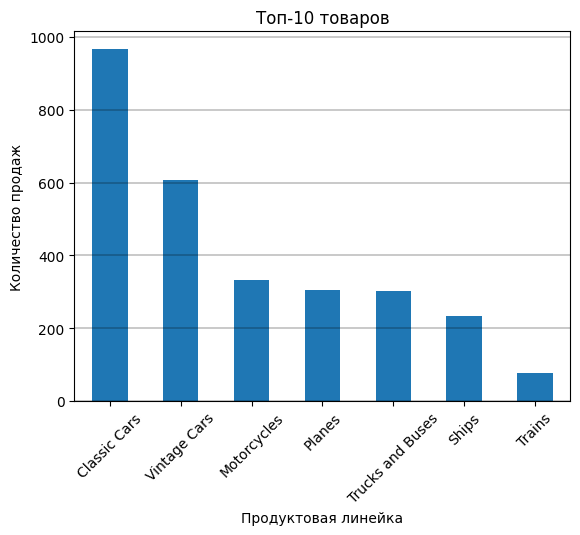

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("sales_data_sample.csv", encoding="latin1")

# Топ-10 товаров

top_products = df["PRODUCTLINE"].value_counts().head(10)
top_products.plot(kind="bar")
plt.title("Топ-10 товаров")
plt.ylabel("Количество продаж")
plt.xlabel("Продуктовая линейка")
plt.xticks(rotation=45)
plt.grid(axis='y', color='black', linewidth=0.3)
plt.show()

Text(0.5, 0, '')

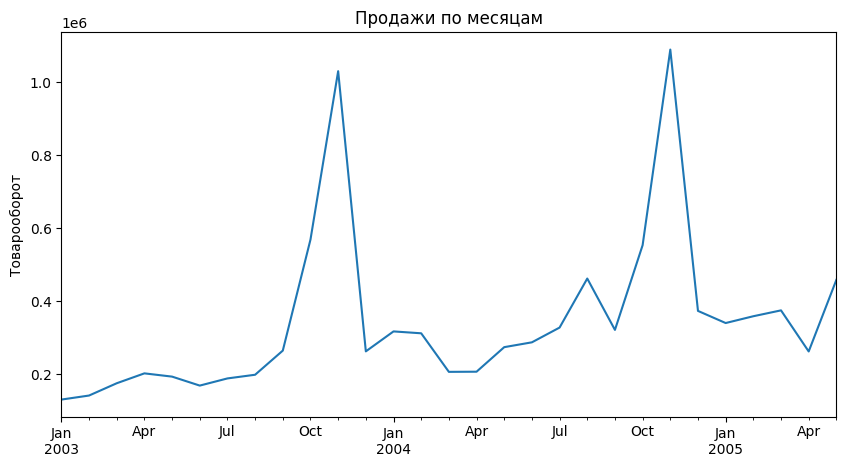

In [25]:
# Продажи по месяцам
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])

df.groupby(df['ORDERDATE'].dt.to_period('M'))['SALES'].sum().plot(kind='line', figsize=(10,5))
plt.title("Продажи по месяцам")
plt.ylabel("Товарооборот")
plt.xlabel(None)

Text(0.5, 0, 'Имена заказчиков')

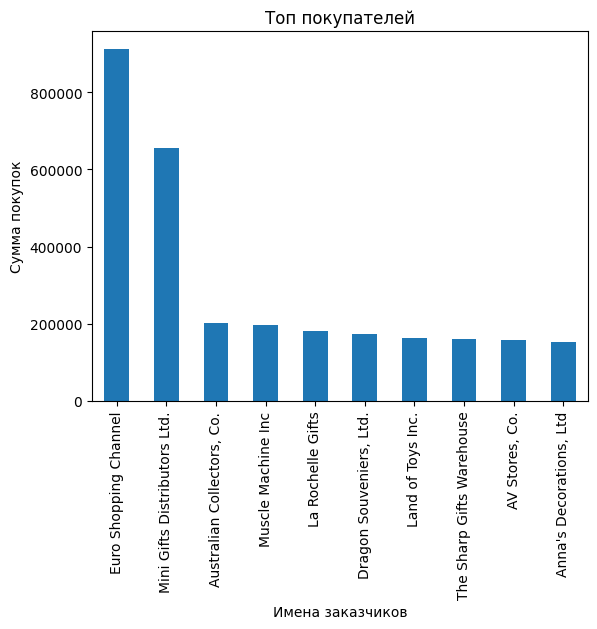

In [26]:
# Топ лучших клиентов
df.groupby('CUSTOMERNAME')['SALES'].sum().sort_values(ascending=False).head(10).plot(kind='bar', xlabel='Customer Name')

plt.title("Топ покупателей")
plt.ylabel("Сумма покупок")
plt.xlabel("Имена заказчиков")

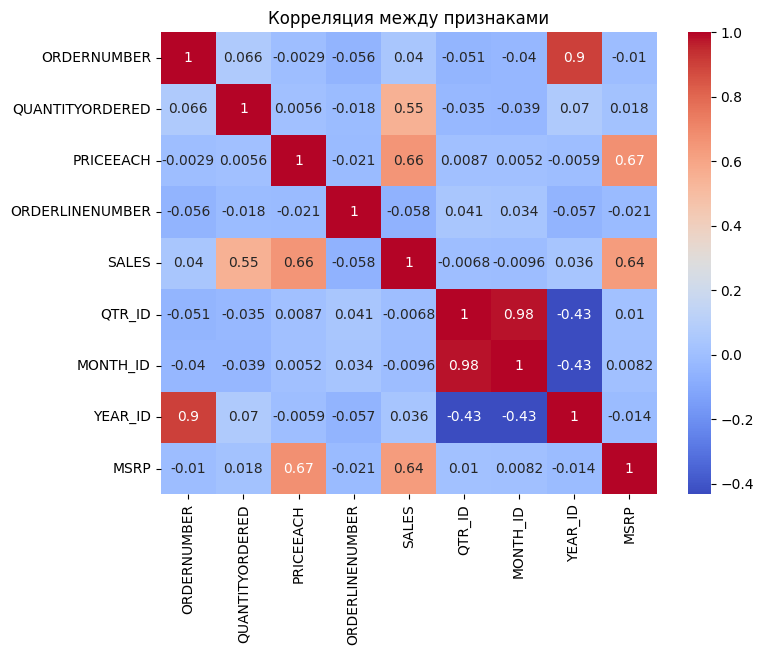

In [27]:
import seaborn as sns

# Матрица корелляции между признаками

corr = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Корреляция между признаками")
plt.show()

In [28]:
# Дашборд в Plotly (Внутри Colab)

import plotly.express as px
import pandas as pd

df = pd.read_csv("sales_data_sample.csv", encoding="latin1")

df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])

df.columns

df['YearMonth'] = df['ORDERDATE'].dt.to_period('M').astype(str)

monthly_sales = df.groupby('YearMonth')['SALES'].sum().reset_index()

fig = px.line(monthly_sales, x='YearMonth', y='SALES', title='Продажи по месяцам')
fig.show()

In [29]:
# Топ 10 заказчиков по продажам
top_clients = df.groupby('CUSTOMERNAME')['SALES'].sum().sort_values(ascending=False).head(10).reset_index()
fig = px.bar(top_clients, x='CUSTOMERNAME', y='SALES', title='Топ 10 заказчиков по продажам')
fig.show()

In [30]:
# Распределение объема продаж по товарным категориям
fig = px.pie(df, names='PRODUCTLINE', values='SALES', title='Распределение объема продаж по товарным категориям')
fig.show()